In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error

In [3]:
df=pd.read_csv('student_performance_dataset.csv')
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [6]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [4]:
print(df.isna().sum())

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


In [5]:
df['parental_education']=df['parental_education'].fillna(df['parental_education'].mode()[0])
df['parental_education']=df['parental_education'].map({
    'High School':0,
    'Associate':1,
    'Bachelors':2,
    'Masters':3,
    'PhD':4
})
df['extracurricular_activities']=df['extracurricular_activities'].map({'Yes':1,'No':0})
df['part_time_job']=df['part_time_job'].map({'Yes':1,'No':0})
df.head()
    

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,2,Yes,1,0,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,0,Yes,1,1,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,2,Yes,0,1,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,0,Yes,1,0,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,2,Yes,0,1,61.8,68.3,D


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          1000 non-null   int64  
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   int64  
 8   part_time_job               1000 non-null   int64  
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(4), object(3)
memory usage: 93.9+ KB


In [7]:
print(df.duplicated().sum())

0


In [8]:
x=df[['study_time_hours','attendance_percent','sleep_hours','parental_education','extracurricular_activities','part_time_job']]
y=df['final_exam_score']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [10]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
score_predict=model.predict(x_test)
print(score_predict)

[ 80.29892002  72.35968718  80.00582156  90.06216775  83.45846201
  81.32966673  92.89399033  79.27515432  74.54665559  76.1056438
  85.6773528   80.68991604  88.83787946  81.9890911   86.14090601
  79.87066793  80.77757128  88.56520625  68.59678916  85.13847361
  78.20677887  84.90532792  88.25313929  96.8340278   84.60067573
  83.60011798  68.69178356  78.71624382  75.4152383   92.99825775
  87.44966376  78.16169723  83.80911726  95.78354181  83.14819788
  89.01891438  79.63028599  84.62565567  87.04844002  86.74074366
  82.97030907  78.37615205  92.70901444  79.48049315  89.42341216
  74.03500828  82.34941492  91.36031413  96.72719761  87.36856455
  77.09152008  79.08085568  85.72981401  87.63373309  85.9620825
  90.70880374  81.85889754  64.44473906  79.13806251  83.88788855
  78.34113028  91.73033997  95.75547551  75.16217638  90.67318681
  93.6870601   93.11724435  68.87772219  85.62259022  90.19672623
  81.9641121   85.02765145  82.91937343  85.90673484  89.66908806
  76.1608611

In [21]:
r2=r2_score(y_test,score_predict)
print(r2)
mse=mean_squared_error(y_test,score_predict)
print(mse)
rmse=root_mean_squared_error(y_test,score_predict)
print(rmse)

0.3871124467349507
65.96935167629098
8.122151911672853


In [12]:
import statsmodels.api as sm
x_train_stat = x_train.astype(float)
x_train_stat = sm.add_constant(x_train_stat) 
stats_model = sm.OLS(y_train, x_train_stat).fit()
print(stats_model.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         35.1996      2.963     11.881      0.000      29.384      41.015
study_time_hours               3.9777      0.184     21.617      0.000       3.617       4.339
attendance_percent             0.3284      0.029     11.428      0.000       0.272       0.385
sleep_hours                    1.0788      0.228      4.731      0.000       0.631       1.526
parental_education             0.1003      0.200      0.501      0.617      -0.293       0.493
extracurricular_activities     0.3365      0.548      0.615      0.539      -0.738       1.411
part_time_job                 -3.9663      0.575     -6.894      0.000      -5.096      -2.837


In [15]:
print(stats_model.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         35.1996      2.963     11.881      0.000      29.384      41.015
study_time_hours               3.9777      0.184     21.617      0.000       3.617       4.339
attendance_percent             0.3284      0.029     11.428      0.000       0.272       0.385
sleep_hours                    1.0788      0.228      4.731      0.000       0.631       1.526
parental_education             0.1003      0.200      0.501      0.617      -0.293       0.493
extracurricular_activities     0.3365      0.548      0.615      0.539      -0.738       1.411
part_time_job                 -3.9663      0.575     -6.894      0.000      -5.096      -2.837


Look at the P>|t| column (the p-value).
1.If it is 0.000, that variable has a massive, guaranteed impact on the final score.
study_time_hours (+3.98 points): This is your strongest positive predictor. For every single extra hour a student studies, their final score increases by roughly 4 points.
2.part_time_job (-3.97 points):Having a part-time job hurts performance significantly. Students working part-time drop nearly 4 points compared to peers who do not work.
3.sleep_hours (+1.08 points): Sleep matters. For every additional hour of sleep a student gets, their exam score rises by about 1.1 points.
4.attendance_percent (+0.33 points): Attendance is crucial. Because this is a percentage, a 10% increase in class attendance translates to roughly 3.3 points gained on the exam.
5.const (35.20 points): This is the baseline intercept. If a student slept 0 hours, studied 0 hours, had 0% attendance, and had no job, their baseline starting score is mathematically estimated at 35.2 points.
6.The Variables to Ignore(Statistically Insignificant)If the p-value is high (typically greater than 0.05), the variable has no reliable effect on the exam score in this model. You can ignore these coefficients:parental_education (p = 0.617): The coefficient of 0.10 is meaningless because the high p-value shows this variation is likely just random noise.extracurricular_activities (p = 0.539): Doing extra activities has no statistically verifiable positive or negative impact on the grade.
Summary Equation for PredictionsYou can use these significant variables to manually estimate a student's score using this formula:
exam score=35.20+(3.98* study hours)+(0.33*attendance)+(1.08*sleep hours)-(3.97*part time job)

In [17]:
x=df[['study_time_hours','attendance_percent','sleep_hours','part_time_job']]
y=df['final_exam_score']

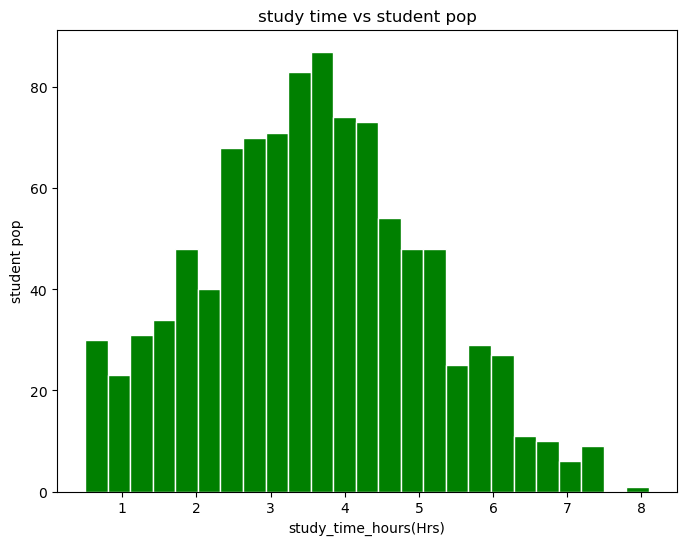

In [29]:
plt.figure(figsize=(8,6))
plt.hist(df['study_time_hours'],bins=25,color='green',edgecolor='white')
plt.title('study time vs student pop')
plt.xlabel('study_time_hours(Hrs)')
plt.ylabel('student pop')
plt.show()

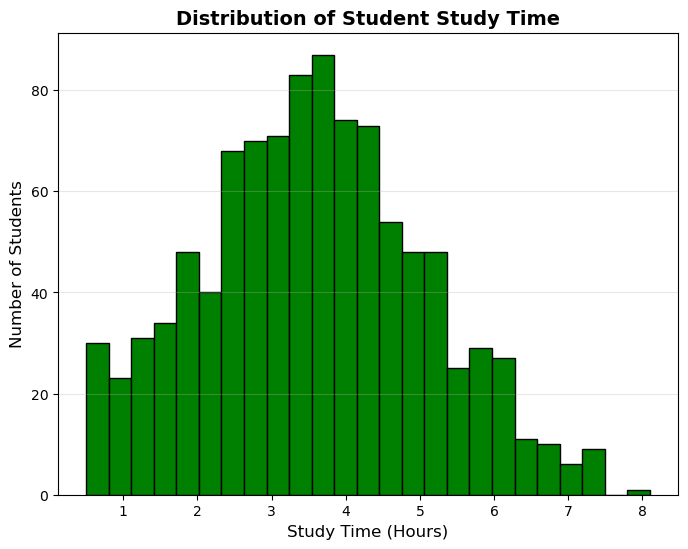

In [25]:
plt.figure(figsize=(8, 6))
# Added edgecolor to make individual bars pop out cleanly
plt.hist(df['study_time_hours'], bins=25, color='green', edgecolor='black')

# Cleaned up labels for standard presentation formatting
plt.title('Distribution of Student Study Time', fontsize=14, fontweight='bold')
plt.xlabel('Study Time (Hours)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Optional: adds a subtle grid behind the bars to make reading counts easier
plt.grid(axis='y', alpha=0.3) 

plt.show()

The Shape of the Distribution:  the features are often synthetically generated with a normal (bell-shaped) distribution. You will likely see a large peak in the middle (the average study time) with the student population tapering off symmetrically toward 0 hours and high hours.
The Center: The highest green bar will show you the most common study duration among the students.
Outliers: The edges of the histogram will show you if there are extreme cases—such as students studying close to 0 hours or pushing past 20+ hours.

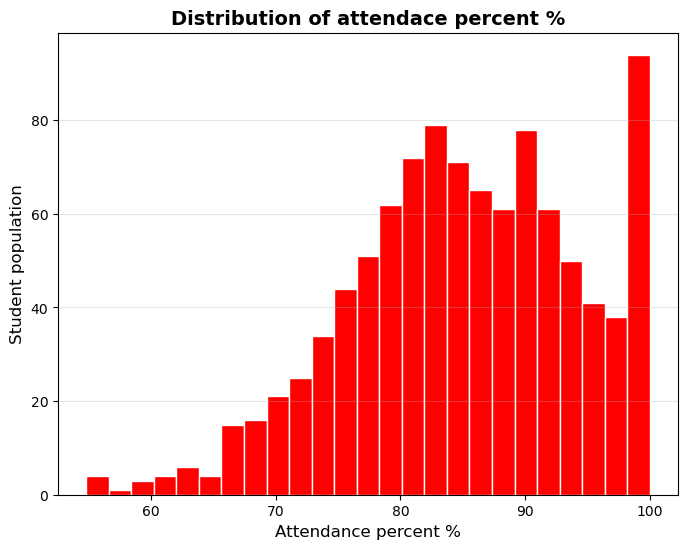

In [33]:
plt.figure(figsize=(8,6))
plt.hist(df['attendance_percent'],bins=25,color='red',edgecolor='white')
plt.title('Distribution of Attendace percent %',fontsize=14,fontweight='bold')
plt.xlabel('Attendance percent %', fontsize=12)
plt.ylabel('Student population', fontsize=12)
plt.grid(axis='y',alpha=0.3)
plt.show()

 specific structural patterns:Left-Skewed Distribution: In typical educational datasets, attendance is heavily skewed to the left. You will likely see a massive cluster of high bars stacked on the right side (between 85% and 100%), with a long, thin tail stretching out to the left toward lower attendance percentages.The Baseline Drops: Because attendance has a strict ceiling at 100%, the data will abruptly cut off on the far right. The peak of this curve will instantly show you the "normal" attendance rate for the vast majority of your student population.The At-Risk Zone: The bars on the far left (e.g., students with under 70% attendance) represent your outliers. These are the specific students driving down the attendance coefficient you saw in your regression model earlier.

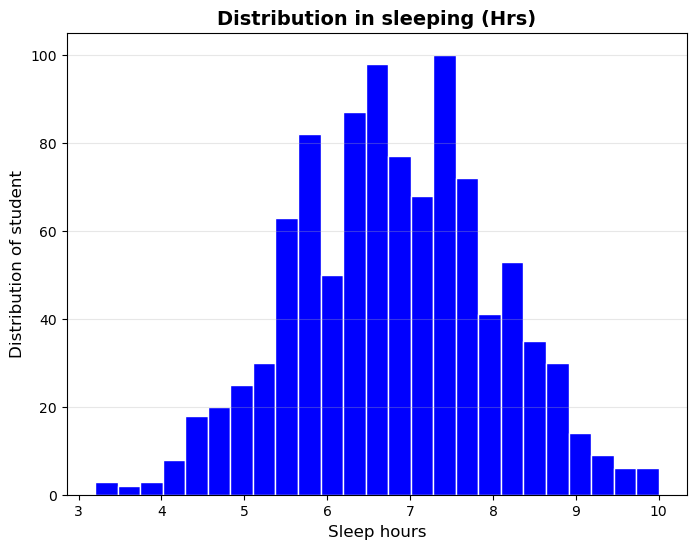

In [49]:
plt.figure(figsize=(8,6))
plt.hist(df['sleep_hours'],bins=25,color='blue',edgecolor='white')
plt.title('Distribution in sleeping (Hrs)',fontsize=14,fontweight='bold')
plt.xlabel('Sleep hours', fontsize=12)
plt.ylabel('Distribution of student', fontsize=12)
plt.grid(axis='y',alpha=0.3)
plt.show()

 specific structural patterns:A Discrete Bell Curve: In this specific Kaggle dataset, sleep_hours is typically recorded as discrete whole numbers (e.g., 5, 6, 7, 8, 9, 10). Because of this, you will see a symmetric, bell-shaped distribution with gaps or tight clusters around these specific hourly markers.The Sweet Spot (The Peak): The highest blue bars will likely cluster around 7 and 8 hours, showing that the vast majority of students fall into the recommended or near-recommended sleep window.The Extremes: You will instantly see the small populations of students on the far left (sleeping 4–5 hours) and the far right (sleeping 9–10 hours). Connecting this back to your regression model, those sleep-deprived students on the far left are losing roughly 1.08 points per hour of missed sleep.

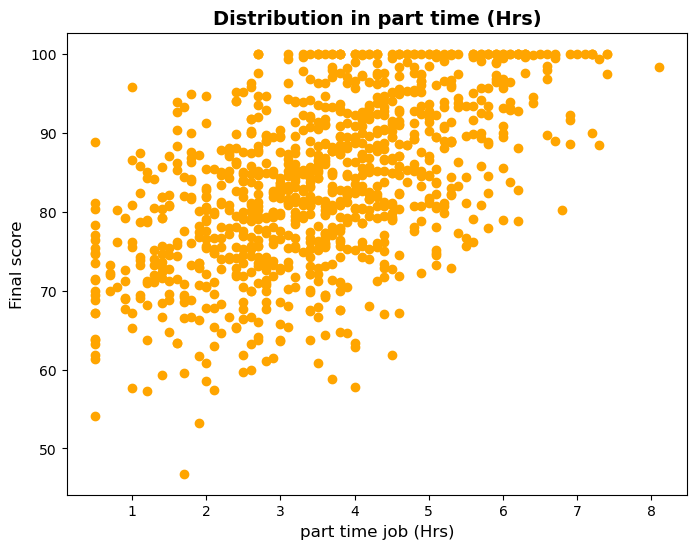

In [42]:
x=df[['study_time_hours']]
y=df['final_exam_score']
plt.figure(figsize=(8,6))
plt.scatter(x,y,color='orange')
plt.title('Distribution in part time (Hrs)',fontsize=14,fontweight='bold')
plt.xlabel('part time job (Hrs)', fontsize=12)
plt.ylabel('Final score', fontsize=12)
plt.show()

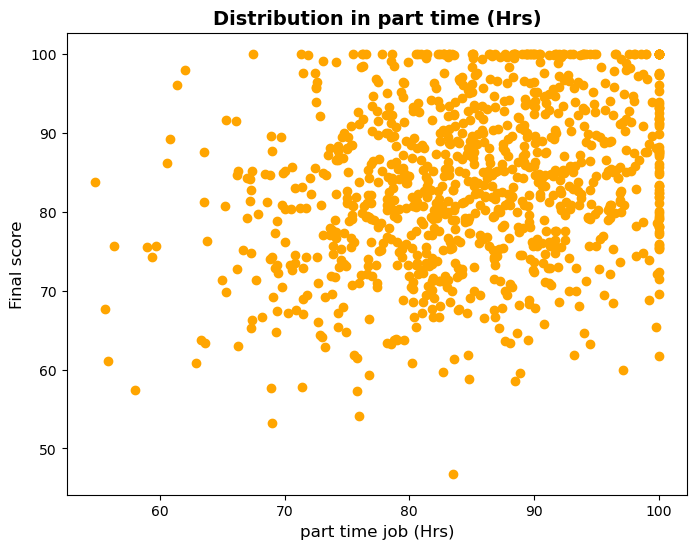

In [44]:
x=df[['attendance_percent']]
y=df['final_exam_score']
plt.figure(figsize=(8,6))
plt.scatter(x,y,color='orange')
plt.title('Distribution in part time (Hrs)',fontsize=14,fontweight='bold')
plt.xlabel('part time job (Hrs)', fontsize=12)
plt.ylabel('Final score', fontsize=12)
plt.show()

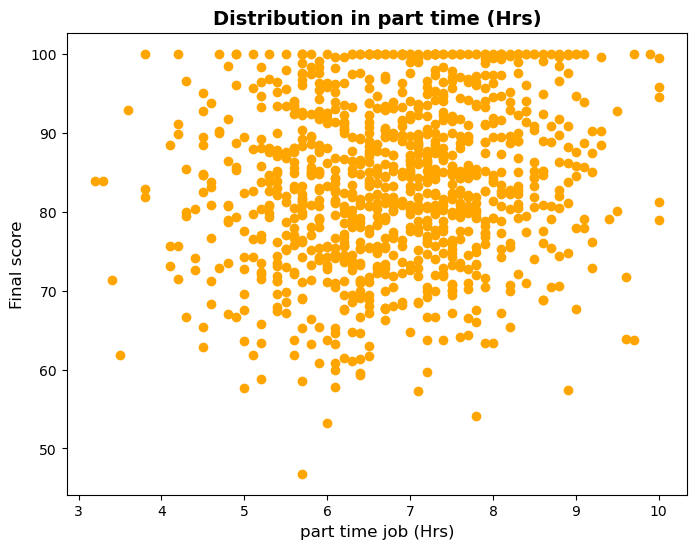

In [45]:
x=df[['sleep_hours']]
y=df['final_exam_score']
plt.figure(figsize=(8,6))
plt.scatter(x,y,color='orange')
plt.title('Distribution in part time (Hrs)',fontsize=14,fontweight='bold')
plt.xlabel('part time job (Hrs)', fontsize=12)
plt.ylabel('Final score', fontsize=12)
plt.show()

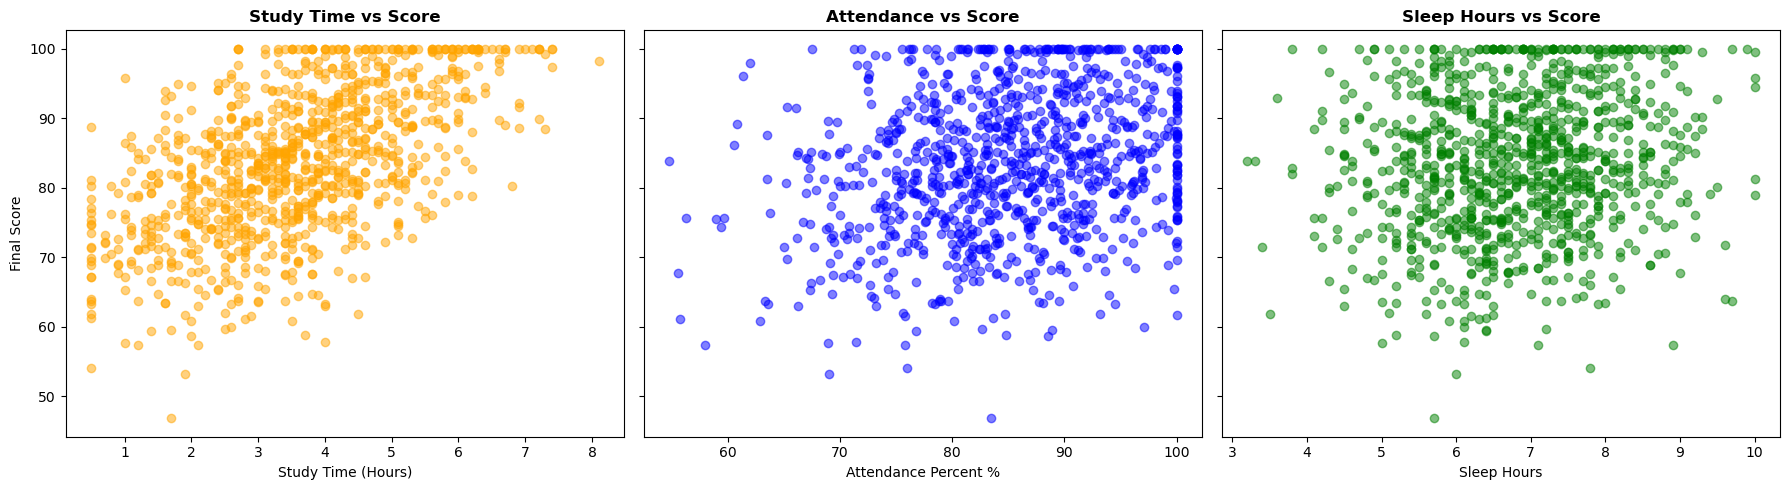

In [48]:
# 1. Define your target variable (ensure this matches your exact column name)
y = df['final_exam_score'] # or df['final_exam_score'] / df['G3']

# 2. Set up a 1-row, 3-column layout of plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot 1: Study Time vs Score
axes[0].scatter(df['study_time_hours'], y, color='orange', alpha=0.5)
axes[0].set_title('Study Time vs Score', fontweight='bold')
axes[0].set_xlabel('Study Time (Hours)')
axes[0].set_ylabel('Final Score')

# Plot 2: Attendance vs Score
axes[1].scatter(df['attendance_percent'], y, color='blue', alpha=0.5)
axes[1].set_title('Attendance vs Score', fontweight='bold')
axes[1].set_xlabel('Attendance Percent %')

# Plot 3: Sleep Hours vs Score
axes[2].scatter(df['sleep_hours'], y, color='green', alpha=0.5)
axes[2].set_title('Sleep Hours vs Score', fontweight='bold')
axes[2].set_xlabel('Sleep Hours')

# Clean up layout spacing and render
plt.tight_layout()
plt.show()